In [1]:
# Cell 1 -- Imports and load the trained baseline model + one real image
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from data_prep import load_and_preprocess_data, CLASS_NAMES

# We load the ALREADY TRAINED baseline model -- this step is not about
# training anything new, only about re-implementing the forward pass
# using the real weights this model already learned.
model = tf.keras.models.load_model("../models/baseline_cnn.keras")
_ = model(np.zeros((1, 28, 28, 1), dtype="float32"))  # warm-up, same fix from Step 8

_, _, X_test, y_test = load_and_preprocess_data()

# Pick one real test image to run our manual implementation on.
test_image = X_test[0]
print(f"Test image shape: {test_image.shape}, true label: {CLASS_NAMES[y_test[0]]}")

Raw shapes -- X_train: (60000, 28, 28), X_test: (10000, 28, 28)
Raw dtype: uint8, raw value range: 0-255
After normalization -- dtype: float32, value range: 0.0-1.0
After reshaping -- X_train: (60000, 28, 28, 1), X_test: (10000, 28, 28, 1)
Test image shape: (28, 28, 1), true label: Ankle boot


In [2]:
# Cell 2 -- Manual convolution, implemented from scratch with plain loops

def manual_conv2d(image, filters, biases, padding="same"):
    """
    Performs a 2D convolution (technically cross-correlation, matching
    what Keras actually does) by hand, using plain nested loops.

    image:   shape (height, width, input_channels)
    filters: shape (kernel_h, kernel_w, input_channels, output_filters)
             -- this is EXACTLY the shape Keras stores Conv2D weights in,
             so we can plug real trained weights straight into this
             function with no conversion needed.
    biases:  shape (output_filters,)

    Returns: shape (height, width, output_filters) if padding='same'
    """
    img_h, img_w, in_channels = image.shape
    kernel_h, kernel_w, _, out_filters = filters.shape

    if padding == "same":
        # For a 3x3 kernel, pad 1 pixel on every side so the output
        # stays the same height/width as the input. This formula
        # generalizes to other odd kernel sizes too (5x5 -> pad 2, etc).
        pad_h = (kernel_h - 1) // 2
        pad_w = (kernel_w - 1) // 2
        # np.pad adds zeros around the image. We only pad the height/width
        # dimensions (the first two), not the channel dimension (the third)
        # -- hence (0, 0) for that axis.
        padded_image = np.pad(
            image, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode="constant"
        )
    else:
        padded_image = image

    # Output has the same height/width as the ORIGINAL image (since we
    # padded specifically to preserve that), and one channel per filter.
    output = np.zeros((img_h, img_w, out_filters))

    # The main triple loop: for every output pixel position, for every
    # output filter, compute one convolution result.
    for y in range(img_h):
        for x in range(img_w):
            # Extract the small window of the (padded) image that this
            # filter will look at, centered at this output position.
            window = padded_image[y:y + kernel_h, x:x + kernel_w, :]

            for f in range(out_filters):
                # Element-wise multiply the window by this filter's
                # weights, then sum everything into one number -- this
                # IS the convolution operation, in full.
                output[y, x, f] = np.sum(window * filters[:, :, :, f]) + biases[f]

    return output


def manual_relu(x):
    """
    ReLU (Rectified Linear Unit): keeps positive values unchanged,
    replaces every negative value with 0. This is literally a one-line
    operation -- np.maximum compares element-wise and keeps the larger
    of the two values at every position.
    """
    return np.maximum(0, x)

In [3]:
# Cell 3 -- Extract the REAL trained weights from the model's first conv layer
first_conv_layer = model.get_layer("conv2d")  # matches your Step 4 architecture's first Conv2D
real_filters, real_biases = first_conv_layer.get_weights()

print(f"Extracted filter weights shape: {real_filters.shape}")
print(f"Extracted bias shape: {real_biases.shape}")

Extracted filter weights shape: (3, 3, 1, 8)
Extracted bias shape: (8,)


In [4]:
# Cell 4 -- Run OUR manual implementation using the model's real weights
manual_output = manual_conv2d(test_image, real_filters, real_biases, padding="same")
manual_output_with_relu = manual_relu(manual_output)

print(f"Manual output shape: {manual_output_with_relu.shape}")

Manual output shape: (28, 28, 8)


In [5]:
# Cell 5 -- THE KEY TEST: get Keras's own output for the same layer,
# same image, and compare against our manual result

# Build a small model that stops right after the first conv layer,
# so we can see exactly what Keras itself computed at that point --
# same technique from Step 7's visualize_feature_maps().
keras_first_layer_model = tf.keras.Model(
    inputs=model.inputs, outputs=model.get_layer("conv2d").output
)
image_batch = np.expand_dims(test_image, axis=0)
keras_output = keras_first_layer_model.predict(image_batch, verbose=0)[0]

print(f"Keras output shape: {keras_output.shape}")

# Compare the two outputs. We use np.allclose instead of exact equality
# (==) because floating-point arithmetic can differ by tiny rounding
# errors depending on computation order -- allclose checks "close enough"
# within a small tolerance, which is the correct way to compare floats.
match = np.allclose(manual_output_with_relu, keras_output, atol=1e-5)
max_difference = np.max(np.abs(manual_output_with_relu - keras_output))

print(f"\nDo the manual and Keras outputs match? {match}")
print(f"Maximum difference between them: {max_difference:.10f}")

Keras output shape: (28, 28, 8)

Do the manual and Keras outputs match? True
Maximum difference between them: 0.0000000671


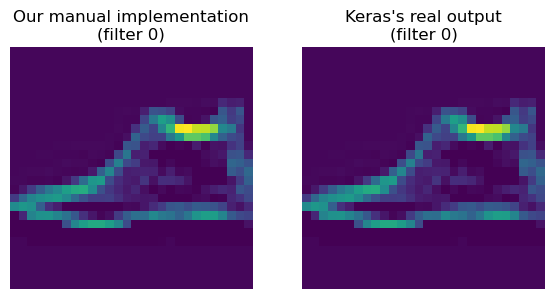

In [6]:
# Cell 6 -- Visual side-by-side confirmation, for one filter channel
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(manual_output_with_relu[:, :, 0], cmap="viridis")
axes[0].set_title("Our manual implementation\n(filter 0)")
axes[0].axis("off")

axes[1].imshow(keras_output[:, :, 0], cmap="viridis")
axes[1].set_title("Keras's real output\n(filter 0)")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/manual_vs_keras_conv.png")
plt.show()